<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/02_TimeSeries_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 실습 B: Time Series Decomposition
**Notebook:** `02_TimeSeries_Decomposition.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 계절성과 추세가 있는 시계열 데이터를 준비합니다.
2. 결측치를 보간하고 월별 빈도로 정리합니다.
3. 이동평균을 이용해 장기 흐름을 간단히 확인합니다.
4. `seasonal_decompose()`를 이용해 시계열을 **Observed / Trend / Seasonal / Residual** 로 분해합니다.
5. `STL` 분해를 이용해 보다 유연한 계절 분해를 수행합니다.
6. 가법(Additive)과 승법(Multiplicative) 구조의 차이를 직관적으로 이해합니다.

---

## 왜 이 실습이 중요한가?
시계열을 바로 예측하기 전에, 먼저 데이터가 어떤 구조로 이루어져 있는지 이해해야 합니다.  
시계열 분해는 데이터 속에 숨어 있는 **장기 추세**, **반복적 계절성**, **설명되지 않는 잔차**를 분리하여 보여주는 가장 직관적인 도구입니다.


In [ ]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.


In [ ]:
# ============================================
# 2. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 2. 예시 데이터 불러오기: CO2 시계열
이번 실습에서는 `statsmodels`에 포함된 **대기 중 CO2 농도 데이터**를 사용합니다.

이 데이터는
- 장기 추세가 존재하고
- 계절성이 분명하며
- 일부 결측치가 포함되어 있어

시계열 분해 실습에 매우 적합합니다.


In [ ]:
# ============================================
# 3. CO2 데이터 로드
# ============================================

import statsmodels.api as sm

co2 = sm.datasets.co2.load_pandas().data.copy()

print("원본 데이터 크기:", co2.shape)
display(co2.head())


원본 데이터 크기: (2284, 1)


,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


## 3. 데이터 구조와 결측 확인
시계열 분해를 수행하기 전에 다음을 확인해야 합니다.

1. 인덱스가 날짜형인지
2. 결측치가 얼마나 있는지
3. 데이터의 빈도가 무엇인지


In [ ]:
# ============================================
# 4. 데이터 구조 확인
# ============================================

print("===== info =====")
print(co2.info())

print("\n===== index type =====")
print(type(co2.index))

print("\n===== missing values =====")
print(co2.isna().sum())

print("\n===== inferred frequency =====")
try:
    print(pd.infer_freq(co2.index))
except Exception as e:
    print("빈도 추정 실패:", e)


===== info =====
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2284 entries, 1958-03-29 to 2001-12-29
Freq: W-SAT
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   co2     2225 non-null   float64
dtypes: float64(1)
memory usage: 35.7 KB
None

===== index type =====
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>

===== missing values =====
co2    59
dtype: int64

===== inferred frequency =====
W-SAT


## 4. 결측치 처리와 월별 재표집
CO2 데이터는 주간 관측과 결측을 포함하고 있습니다.  
여기서는 다음 절차를 따릅니다.

1. 선형 보간으로 결측치를 메움
2. 월별 평균으로 재표집
3. 월별 시계열로 정리

이렇게 하면 계절 분해를 더 안정적으로 수행할 수 있습니다.


In [ ]:
# ============================================
# 5. 결측치 보간 + 월별 재표집
# ============================================

co2_interp = co2.copy()
co2_interp["co2"] = co2_interp["co2"].interpolate(method="linear")

co2_monthly = co2_interp["co2"].resample("M").mean()

print("월별 데이터 길이:", len(co2_monthly))
print("월별 결측 개수:", co2_monthly.isna().sum())

display(co2_monthly.head())


월별 데이터 길이: 526
월별 결측 개수: 0


,co2
1958-03-31,316.100
1958-04-30,317.200
1958-05-31,317.410
1958-06-30,316.675
1958-07-31,315.625


## 5. 원시 시계열 플롯 확인
먼저 월별 CO2 시계열의 원시 그래프를 그려 장기 추세와 계절성을 눈으로 확인합니다.


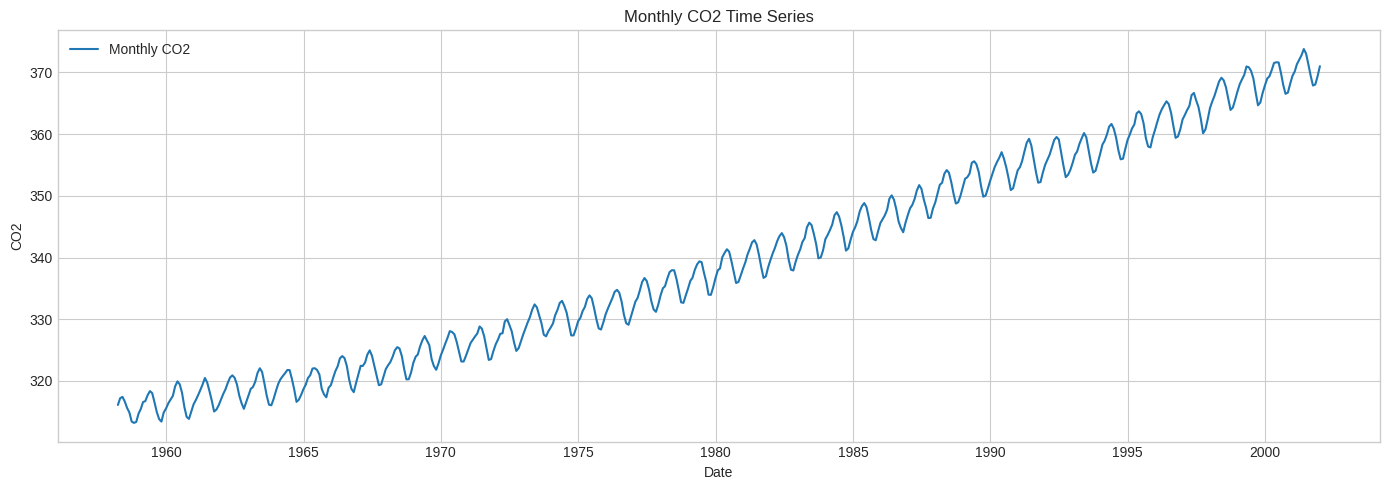

In [ ]:
# ============================================
# 6. 월별 CO2 시계열 플롯
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(co2_monthly.index, co2_monthly, label="Monthly CO2", linewidth=1.5)

plt.title("Monthly CO2 Time Series")
plt.xlabel("Date")
plt.ylabel("CO2")
plt.legend()
plt.tight_layout()
plt.show()


## 6. 이동평균으로 추세를 부드럽게 보기
분해를 하기 전에 간단한 이동평균을 그려 보면 장기 추세를 더 직관적으로 볼 수 있습니다.

여기서는 12개월 이동평균을 사용합니다.


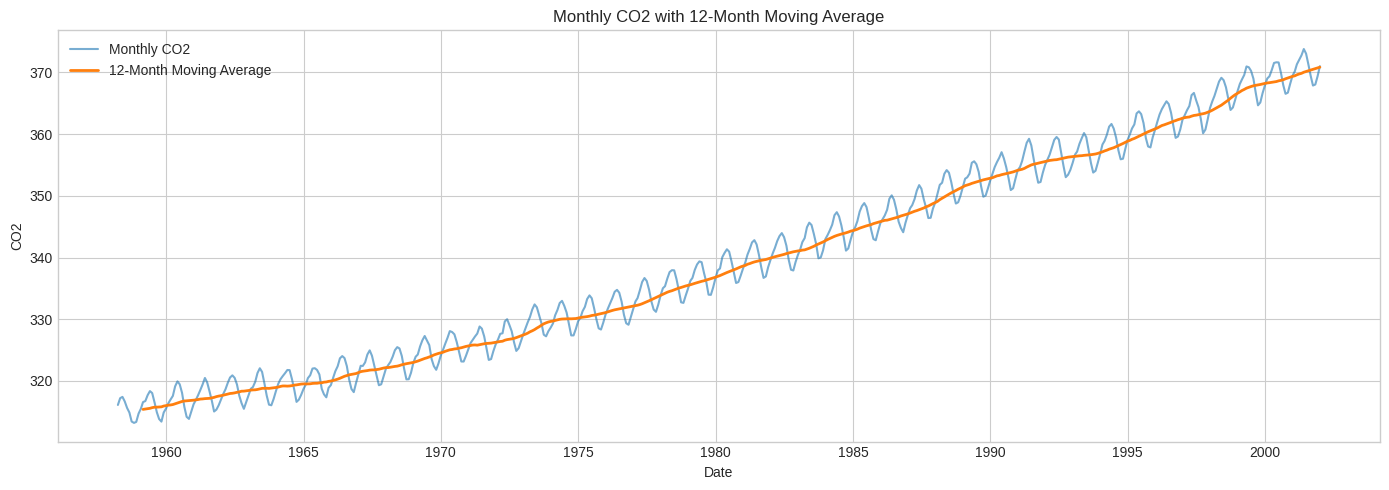

In [ ]:
# ============================================
# 7. 12개월 이동평균
# ============================================

co2_ma12 = co2_monthly.rolling(window=12).mean()

plt.figure(figsize=(14, 5))
plt.plot(co2_monthly.index, co2_monthly, label="Monthly CO2", alpha=0.6)
plt.plot(co2_ma12.index, co2_ma12, label="12-Month Moving Average", linewidth=2)

plt.title("Monthly CO2 with 12-Month Moving Average")
plt.xlabel("Date")
plt.ylabel("CO2")
plt.legend()
plt.tight_layout()
plt.show()


## 7. 가법(Additive) 분해
가법 분해는 시계열을 다음처럼 생각합니다.

- Observed = Trend + Seasonal + Residual

즉, 계절 변동의 크기가 시간에 따라 크게 달라지지 않는다고 가정합니다.


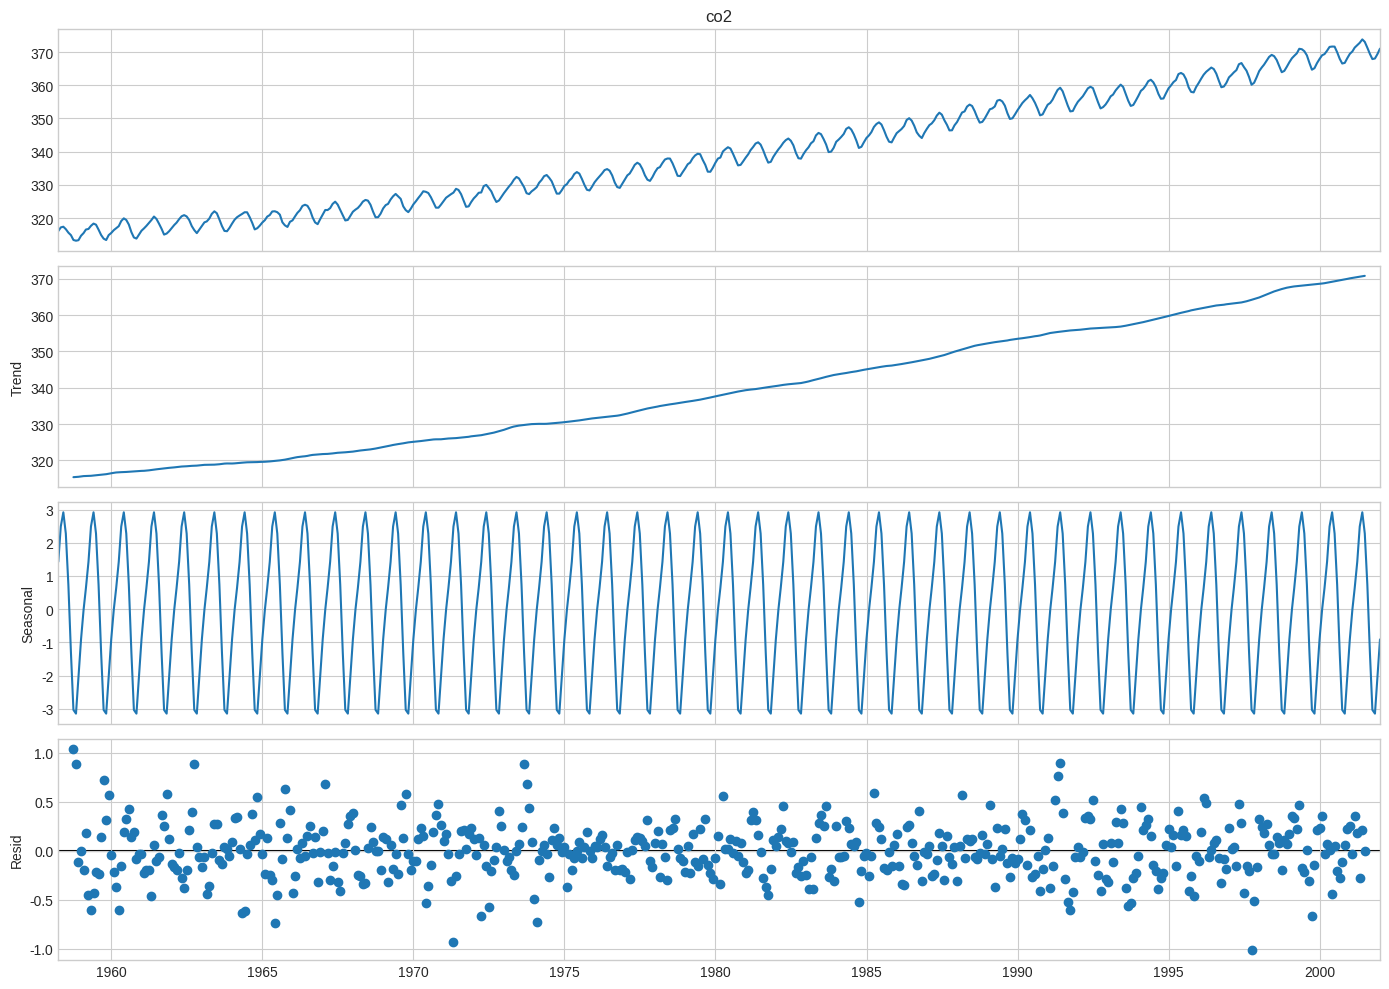

In [ ]:
# ============================================
# 8. Additive decomposition
# ============================================

from statsmodels.tsa.seasonal import seasonal_decompose

decomp_add = seasonal_decompose(co2_monthly, model="additive", period=12)

fig = decomp_add.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


## 8. 분해 결과 해석 포인트
분해 그래프에서는 각 패널을 다음처럼 읽습니다.

- **Observed**: 원래 데이터
- **Trend**: 장기 방향성
- **Seasonal**: 반복적 계절 패턴
- **Resid**: 추세와 계절성으로 설명되지 않는 부분

좋은 분해 결과라면 Residual에 뚜렷한 규칙성이 많이 남지 않아야 합니다.


In [ ]:
# ============================================
# 9. 계절 성분과 잔차 확인
# ============================================

components_df = pd.DataFrame({
    "Observed": decomp_add.observed,
    "Trend": decomp_add.trend,
    "Seasonal": decomp_add.seasonal,
    "Residual": decomp_add.resid
})

display(components_df.head(15))


,Observed,Trend,Seasonal,Residual
1958-03-31,316.100000,NaN,1.426844,NaN
1958-04-30,317.200000,NaN,2.488906,NaN
1958-05-31,317.410000,NaN,2.917420,NaN
1958-06-30,316.675000,NaN,2.277143,NaN
1958-07-31,315.625000,NaN,0.731443,NaN
1958-08-31,314.870000,NaN,-1.316769,NaN
1958-09-30,313.416667,315.410289,-3.034926,1.041303
1958-10-31,313.194444,315.456644,-3.147821,0.885622
1958-11-30,313.351111,315.515602,-2.050811,-0.113680
1958-12-31,314.700000,315.611019,-0.911859,0.000840


## 9. STL 분해
`seasonal_decompose()`는 고전적 방법이고, `STL`은 더 유연하고 강건한 분해 방법입니다.  
특히 이상치나 복잡한 계절 패턴이 있을 때 더 안정적인 결과를 주는 경우가 많습니다.


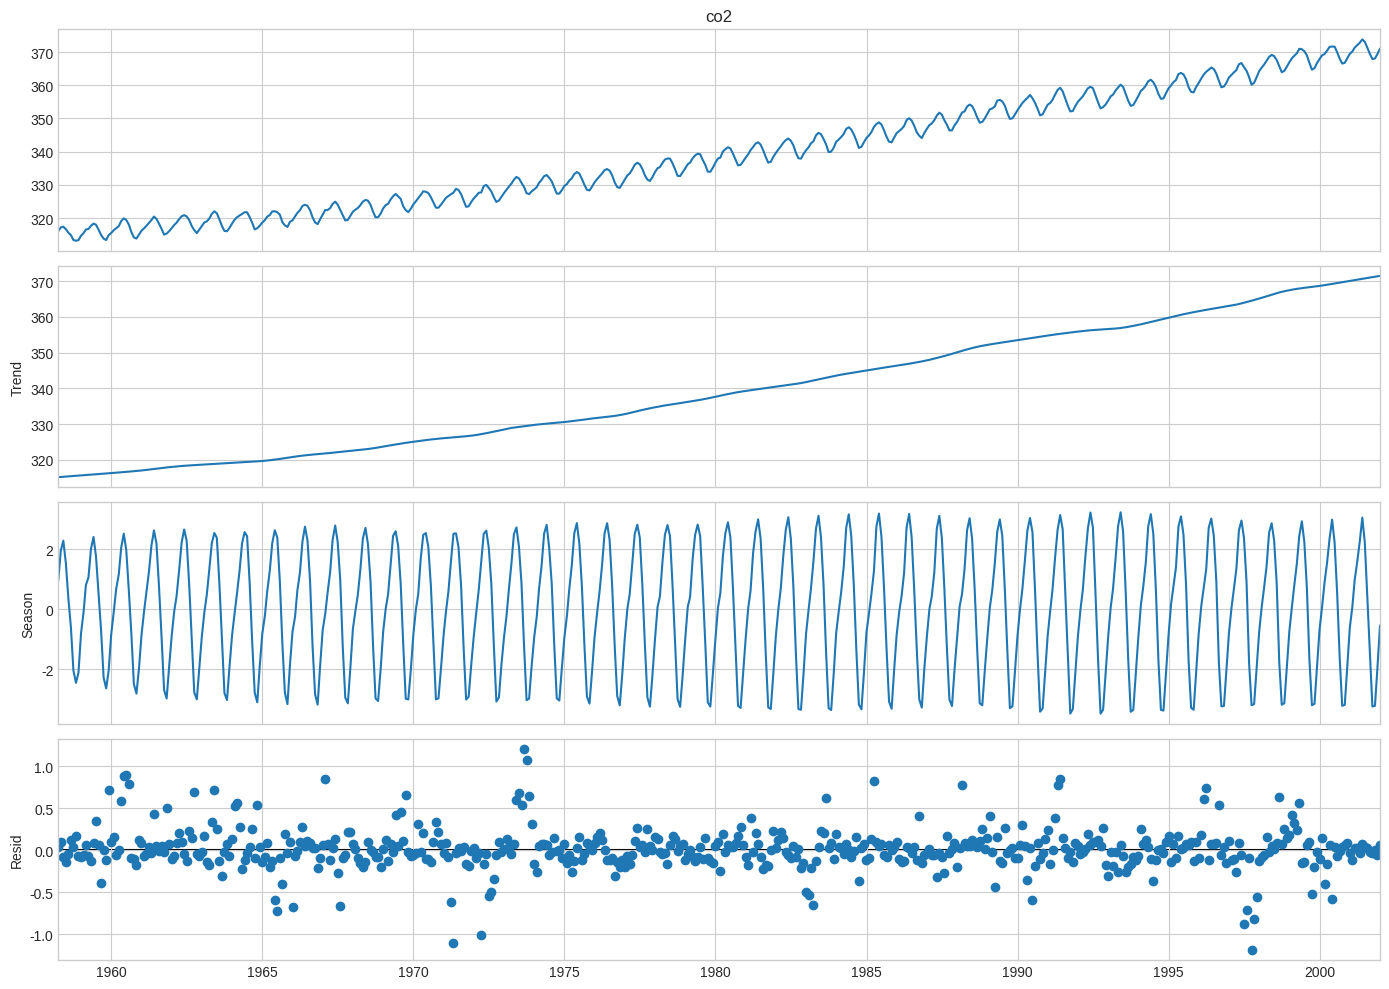

In [ ]:
# ============================================
# 10. STL decomposition
# ============================================

from statsmodels.tsa.seasonal import STL

stl = STL(co2_monthly, period=12, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


## 10. 승법(Multiplicative) 구조를 위한 간단한 예시
어떤 비즈니스 데이터는 수준(level)이 커질수록 계절 진폭도 함께 커집니다.  
이 경우에는 가법 구조보다 승법 구조가 더 자연스러울 수 있습니다.

아래에서는 교육 목적상 **간단한 합성 데이터**를 만들어 승법적 패턴을 보여줍니다.


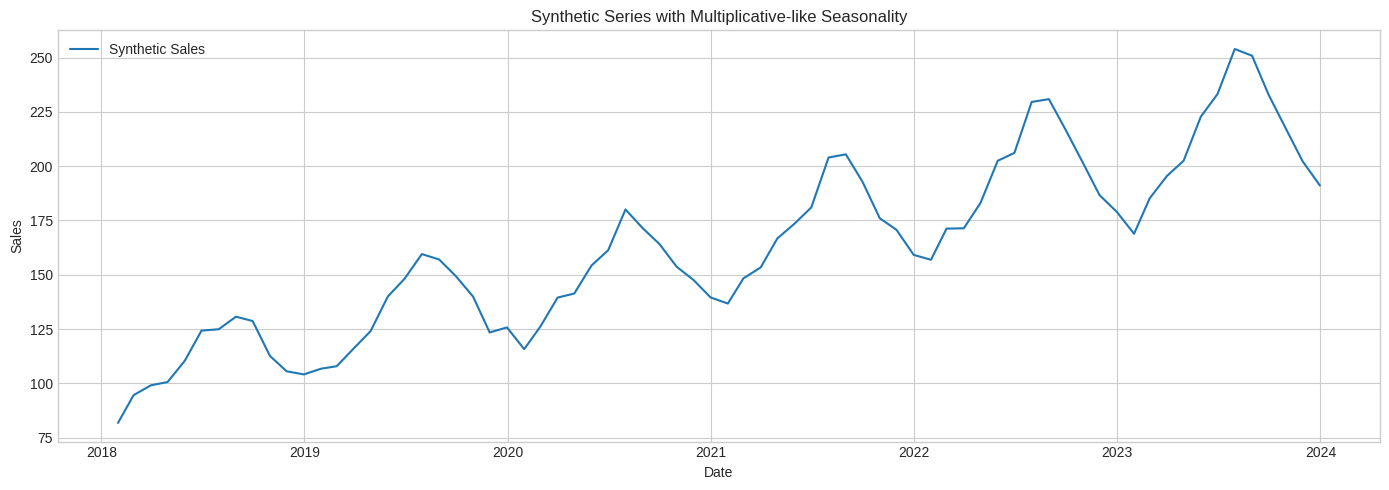

In [ ]:
# ============================================
# 11. Synthetic multiplicative series
# ============================================

np.random.seed(123)

date_idx = pd.date_range(start="2018-01-01", periods=72, freq="M")
trend = np.linspace(100, 220, len(date_idx))
season = np.array([0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20, 1.18, 1.10, 1.00, 0.92, 0.88])
seasonal_pattern = np.tile(season, len(date_idx) // 12)
noise = np.random.normal(0, 3, len(date_idx))

sales = trend * seasonal_pattern + noise
sales_series = pd.Series(sales, index=date_idx, name="Synthetic_Sales")

plt.figure(figsize=(14, 5))
plt.plot(sales_series.index, sales_series, label="Synthetic Sales", linewidth=1.5)
plt.title("Synthetic Series with Multiplicative-like Seasonality")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


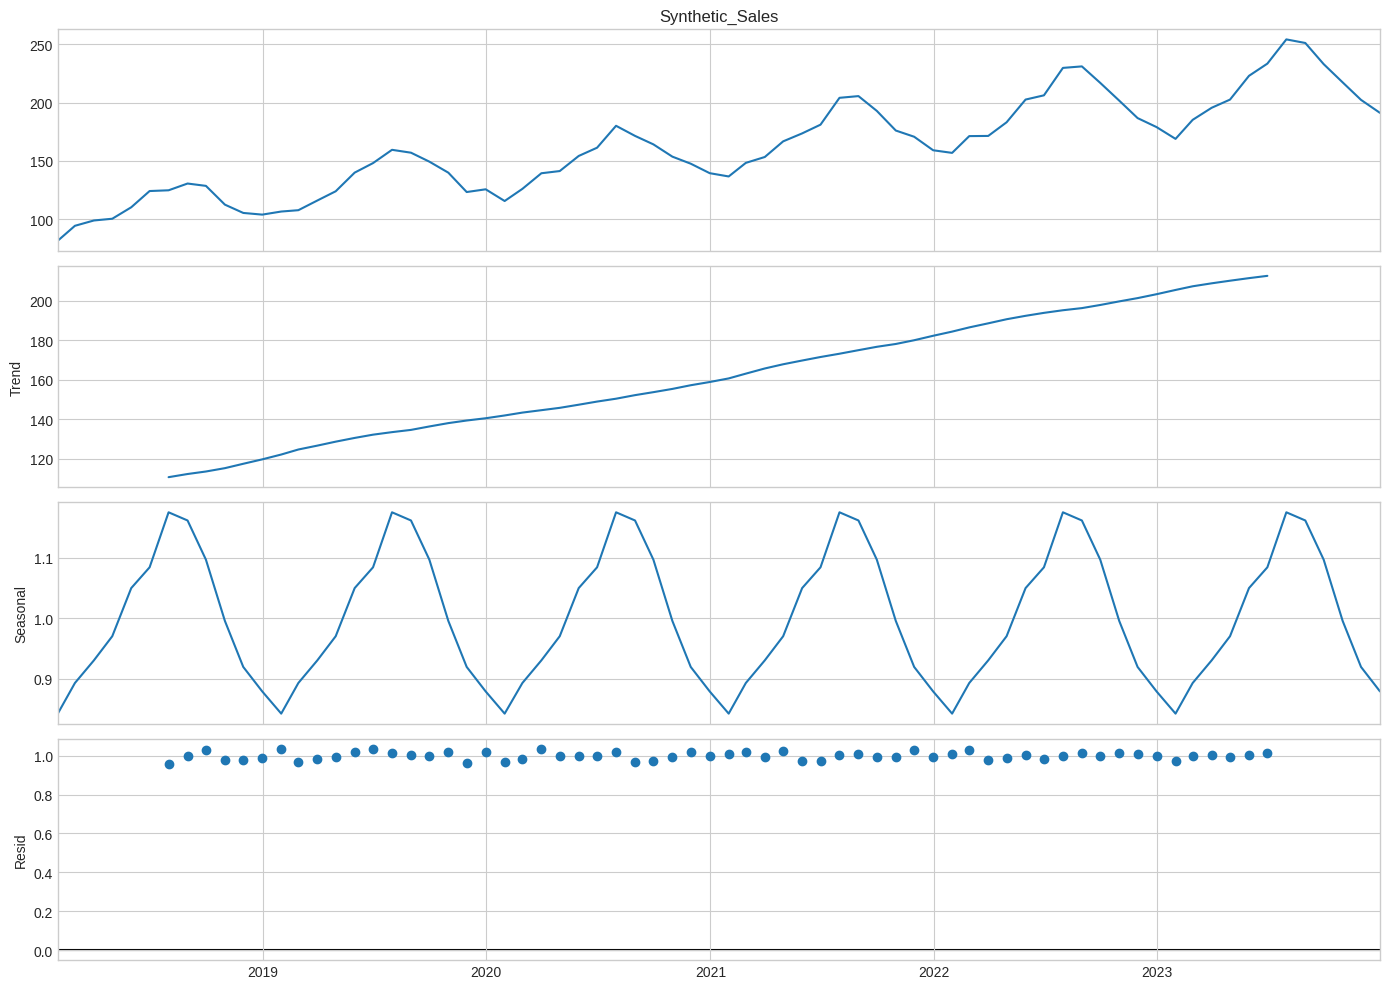

In [ ]:
# ============================================
# 12. Multiplicative decomposition
# ============================================

decomp_mul = seasonal_decompose(sales_series, model="multiplicative", period=12)

fig = decomp_mul.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


## 11. 무엇을 관찰해야 하는가?
이번 실습에서 특히 주의 깊게 볼 부분은 다음과 같습니다.

- 원시 데이터에서 추세가 보이는가?
- 계절성이 일정한 주기로 반복되는가?
- Additive 분해와 STL 분해의 계절 성분이 비슷한가?
- Synthetic series에서는 수준이 커질수록 계절 진폭도 커지는가?
- Residual에 아직 구조가 남아 있는가?


## 12. 실습 정리
이번 실습에서 우리는 시계열 분해의 가장 기초적인 절차를 확인했습니다.

- 결측치를 처리한 뒤 적절한 빈도로 재표집해야 한다.
- 시계열 분해는 데이터의 구조를 먼저 이해하는 탐색적 단계이다.
- Additive 분해는 일정한 계절 진폭을 가정한다.
- Multiplicative 구조는 수준이 커질수록 계절 진폭도 커지는 데이터에 더 적합하다.
- STL은 고전적 분해보다 더 유연하고 실무적으로 유용한 경우가 많다.


## 13. 연습문제 (Exercises)

1. CO2 데이터 대신 다른 월별 시계열 데이터를 불러와 같은 분해를 수행하시오.

2. `period=12` 대신 `period=6`을 넣었을 때 분해 결과가 어떻게 달라지는지 설명하시오.

3. `rolling(window=6).mean()`과 `rolling(window=12).mean()`을 비교하여 추세 곡선이 어떻게 달라지는지 보시오.

4. Synthetic sales series에 더 큰 노이즈를 추가한 뒤 분해 결과가 어떻게 바뀌는지 관찰하시오.

5. Additive와 Multiplicative decomposition 중 어떤 것이 synthetic sales에 더 자연스러운지 자신의 언어로 설명하시오.
